## Bloque 1: Configuración del Entorno y Dependencias

Este bloque establece las bases del proyecto, importando todas las librerías necesarias. **Pandas** y **Numpy** se utilizan para la carga, manipulación y cálculo con datos tabulares. **Matplotlib** y **Seaborn** son las herramientas dedicadas a la visualización gráfica. Finalmente, de **Scikit-Learn (sklearn)** se extraen los algoritmos fundamentales de Machine Learning: el modelo de Regresión Lineal, funciones para dividir los datos y métricas para evaluar el rendimiento del modelo.

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 1: Configuración del Entorno y Dependencias
# --------------------------------------------------------- #

import numpy as np                    # Importa la librería numpy y la renombra como np. Sirve para trabajar con arreglos numéricos y hacer cálculos matemáticos.
import pandas as pd                   # Importa pandas y lo renombra pd. Es la librería principal para manejar datos en tablas (DataFrames).
import matplotlib.pyplot as plt       # Importa matplotlib.pyplot y lo renombra plt. Se usa para crear gráficos.
import seaborn as sns                 # Importa seaborn y lo renombra sns. Permite crear gráficos estadísticos más bonitos y profesionales.
import kagglehub                      # Importa kagglehub. Sirve para descargar datasets directamente desde Kaggle.
import glob                           # Importa glob. Se usa para buscar archivos en carpetas (por ejemplo, buscar el .csv).
import warnings                       # Importa el módulo warnings para controlar mensajes de advertencia.
warnings.filterwarnings('ignore')     # Desactiva todas las advertencias para que la salida del código se vea más limpia.

# Importamos las herramientas de Scikit-learn que vamos a usar
from sklearn.model_selection import train_test_split, cross_val_score, KFold   # Importa funciones para dividir datos y hacer validación cruzada.
from sklearn.preprocessing import StandardScaler                               # Importa el escalador de datos.
from sklearn.linear_model import LinearRegression                              # Importa el modelo de Regresión Lineal.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # Importa las métricas para evaluar el modelo.

# Configuración visual
sns.set_style("whitegrid")                    # Establece un estilo de fondo con cuadrícula blanca para que los gráficos se vean más profesionales.
plt.rcParams['figure.figsize'] = (12, 8)      # Define que todas las figuras tengan un tamaño de 12x8 pulgadas por defecto.

print("✅ Librerías importadas correctamente.\n")   # Imprime un mensaje de confirmación.

✅ Librerías importadas correctamente.



## Bloque 2: Ingesta de Datos (Data Ingestion)

Esta etapa se enfoca en la extracción de datos. El código se conecta de manera dinámica a la API de **Kaggle** para descargar el archivo CSV que contiene la información histórica del brote de Ébola. Una vez descargado, el archivo se lee y se almacena en la memoria del programa como un DataFrame (una tabla estructurada) para su posterior análisis.

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 2: Ingesta de Datos (Data Ingestion)
# --------------------------------------------------------- #

path = kagglehub.dataset_download("imdevskp/ebola-outbreak-20142016-complete-dataset")  # Descarga el dataset desde Kaggle y guarda la ruta en la variable 'path'.
csv_files = glob.glob(path + "/*.csv")          # Busca todos los archivos .csv dentro de la carpeta descargada y los guarda en una lista.
df_long = pd.read_csv(csv_files[0])             # Lee el primer archivo CSV encontrado y lo carga en un DataFrame llamado df_long.

print("✅ Dataset cargado correctamente.")       # Mensaje de confirmación.
print(f"Dimensiones del dataset: {df_long.shape}\n")  # Muestra cuántas filas y columnas tiene el dataset.

Using Colab cache for faster access to the 'ebola-outbreak-20142016-complete-dataset' dataset.
✅ Dataset cargado correctamente.
Dimensiones del dataset: (17585, 4)



## Bloque 3: Transformación y Limpieza de Datos (Data Wrangling)

Esta es la primera fase del preprocesamiento de datos. La tabla original está en un "formato largo", que no es óptimo para el modelado. Usando la función `pivot_table`, los datos se transforman a un "formato ancho", donde cada variable de interés tiene su propia columna. Además, se realiza una limpieza crítica: se eliminan las filas con valores vacíos o nulos (`dropna`), ya que los modelos de Machine Learning no pueden procesar datos incompletos.

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 3: Transformación y Limpieza de Datos (Data Wrangling)
# --------------------------------------------------------- #

df_pivot = df_long.pivot_table(                 # Convierte el dataset de formato largo a formato ancho usando una tabla pivote.
    index=['Date', 'Country'],                  # Usa Fecha y País como índices (identificadores únicos).
    columns='Indicator',                        # Cada valor de la columna 'Indicator' se convierte en una nueva columna.
    values='value'                              # Los valores numéricos se colocan en las celdas.
).reset_index()                                 # Convierte el índice en columnas normales.

df = df_pivot.rename(columns={                  # Renombra las columnas largas a nombres más cortos y fáciles de usar.
    'Cumulative number of confirmed Ebola cases': 'confirmed_cases',
    'Cumulative number of confirmed Ebola deaths': 'confirmed_deaths'
})

df['Date'] = pd.to_datetime(df['Date'])         # Convierte la columna 'Date' de texto a formato de fecha (datetime).
df = df.sort_values('Date')                     # Ordena todo el DataFrame por fecha de forma ascendente.

df_clean = df.dropna(subset=['confirmed_cases', 'confirmed_deaths']).copy()  # Elimina filas que tengan valores nulos en casos o muertes.

print(f"✅ Dataset limpio listo: {df_clean.shape[0]} registros")   # Muestra cuántos registros quedaron después de la limpieza.
print(f"Número de países analizados: {df_clean['Country'].nunique()}\n")  # Muestra cuántos países hay en el dataset.

✅ Dataset limpio listo: 1648 registros
Número de países analizados: 12



## Bloque 4: Análisis Exploratorio Visual (EDA)

Esta sección se dedica al Análisis Exploratorio de Datos (EDA). El objetivo es comprender la naturaleza y distribución de los datos antes de aplicar cualquier modelo estadístico. Se generan histogramas para visualizar la distribución de casos y muertes. La parte más importante es el gráfico de dispersión (scatter plot), que confirma visualmente una relación lineal ascendente entre los casos confirmados y las muertes, lo que justifica el uso de un modelo de regresión lineal.

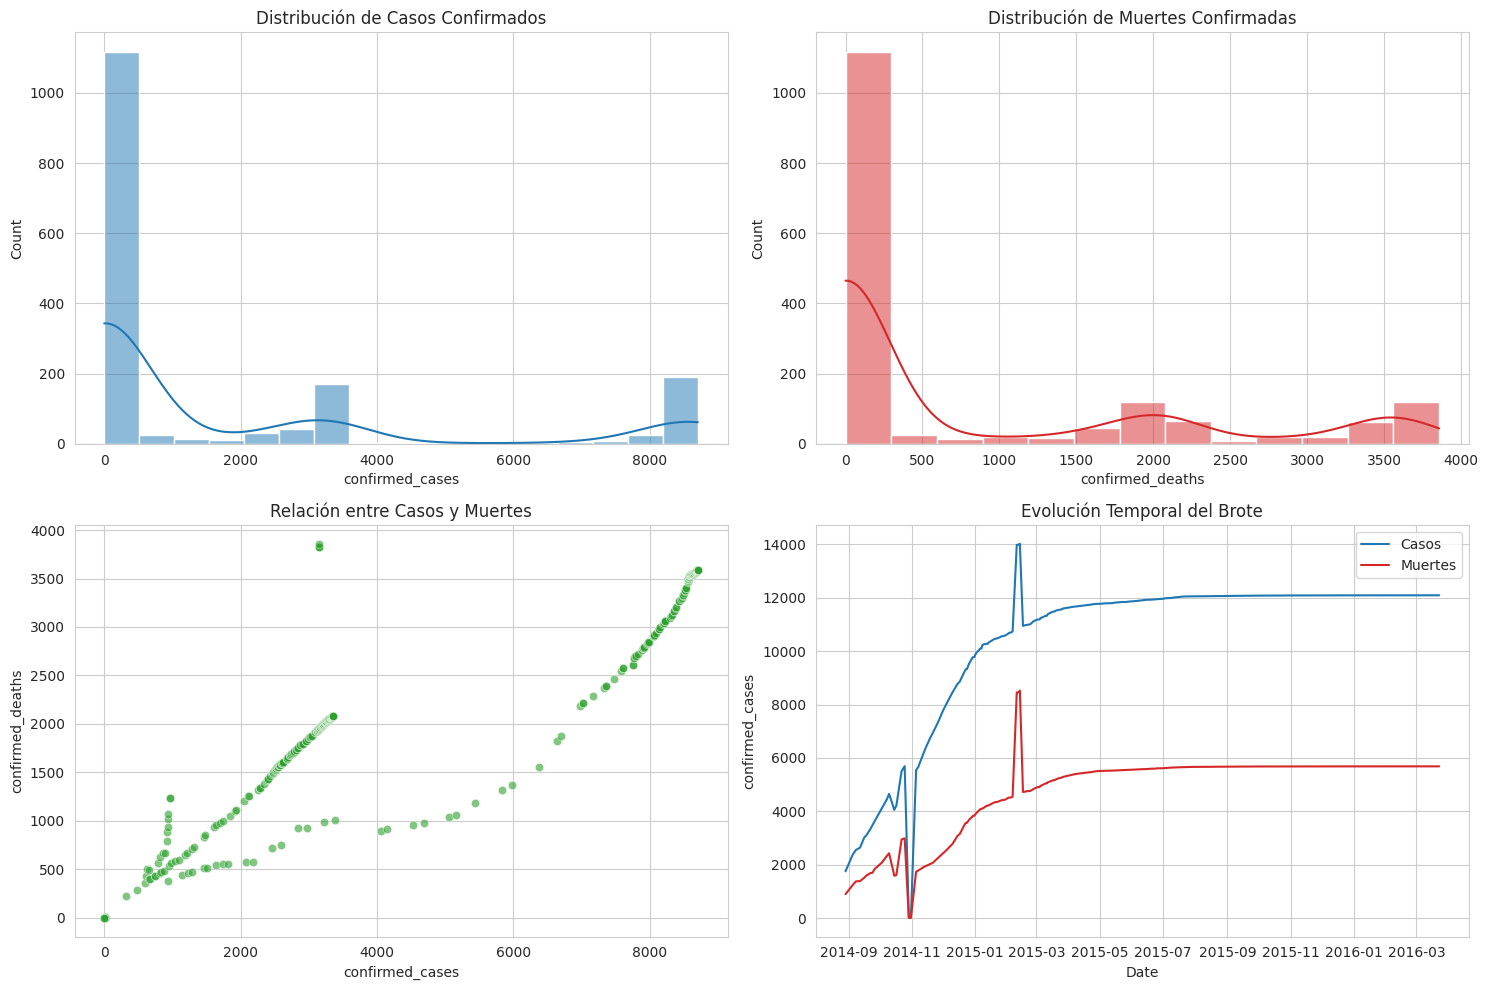

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 4: Análisis Exploratorio Visual (EDA)
# --------------------------------------------------------- #

fig, axes = plt.subplots(2, 2, figsize=(15, 10))   # Crea una figura con 2 filas y 2 columnas de gráficos.

sns.histplot(data=df_clean, x='confirmed_cases', kde=True, ax=axes[0,0], color='#1f77b4')  # Histograma de casos con curva de densidad.
axes[0,0].set_title('Distribución de Casos Confirmados')   # Pone título al gráfico.

sns.histplot(data=df_clean, x='confirmed_deaths', kde=True, ax=axes[0,1], color='#d62728') # Histograma de muertes.
axes[0,1].set_title('Distribución de Muertes Confirmadas')

sns.scatterplot(data=df_clean, x='confirmed_cases', y='confirmed_deaths', alpha=0.6, ax=axes[1,0], color='#2ca02c')  # Gráfico de dispersión.
axes[1,0].set_title('Relación entre Casos y Muertes')

df_total = df_clean.groupby('Date')[['confirmed_cases', 'confirmed_deaths']].sum().reset_index()  # Suma casos y muertes por fecha.
sns.lineplot(data=df_total, x='Date', y='confirmed_cases', ax=axes[1,1], label='Casos', color='#1f77b4')   # Línea de casos.
sns.lineplot(data=df_total, x='Date', y='confirmed_deaths', ax=axes[1,1], label='Muertes', color='#d62728') # Línea de muertes.
axes[1,1].set_title('Evolución Temporal del Brote')

plt.tight_layout()   # Ajusta automáticamente los espacios entre los gráficos.
plt.show()           # Muestra todos los gráficos.

## Bloque 5: Preprocesamiento y Partición de Datos (Data Splitting)

Este bloque contiene el núcleo metodológico del preprocesamiento para Machine Learning, dividido en tres acciones clave:

*   **Definición de variables:** Se establece `X` (la característica predictora o independiente) como los "Casos Confirmados", y `y` (el objetivo o target) como las "Muertes Confirmadas", que es lo que el modelo intentará predecir.

*   **Partición (Split):** Utilizando `train_test_split`, el conjunto de datos se divide rigurosamente: el 80% de los datos se reserva para entrenar el modelo, y el 20% restante se oculta para usarlo exclusivamente en la prueba final. Esto ayuda a prevenir el sobreajuste (overfitting).

*   **Escalado de características:** Los valores de `X` se estandarizan para que tengan una escala uniforme usando `StandardScaler`. El preprocesamiento se ajusta (`fit`) únicamente con el 80% de los datos de entrenamiento para evitar la fuga de información (Data Leakage), y luego esa misma regla de escalado se aplica (`transform`) al 20% de los datos de prueba.

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 5: Preprocesamiento y Partición de Datos (Data Splitting)
# --------------------------------------------------------- #

X = df_clean[['confirmed_cases']]      # Definimos X (variable independiente / predictora). Usamos doble corchete para que sea una matriz 2D.
y = df_clean['confirmed_deaths']       # Definimos y (variable dependiente / target). Es la columna que queremos predecir.

X_train, X_test, y_train, y_test = train_test_split(   # Dividimos los datos en entrenamiento y prueba.
    X, y,
    test_size=0.20,          # Reservamos el 20% de los datos para prueba.
    random_state=42          # Semilla para que la división sea reproducible.
)

scaler = StandardScaler()                              # Creamos el objeto que va a estandarizar los datos.
X_train_scaled = scaler.fit_transform(X_train)         # Ajusta los parámetros (media y desviación) y transforma los datos de entrenamiento.
X_test_scaled = scaler.transform(X_test)               # Solo transforma los datos de prueba (usando los parámetros del entrenamiento).

print("✅ Datos preparados correctamente para el modelado.\n")

✅ Datos preparados correctamente para el modelado.



## Bloque 6: Entrenamiento, Validación Cruzada y Ecuación del Modelo

Aquí es donde el algoritmo aprende. El modelo de **Regresión Lineal** analiza el 80% de los datos de entrenamiento para calcular la mejor línea recta que relaciona los casos con las muertes. Una vez entrenado, se evalúa su capacidad predictiva usando la métrica `R²` tanto en los datos de entrenamiento como en los de prueba. Para asegurar que la alta precisión no sea una coincidencia, se realiza una **Validación Cruzada (K-Fold)**, sometiendo al modelo a 5 pruebas diferentes rotando los datos. Finalmente, se obtiene la ecuación matemática exacta que el modelo formuló a partir de los datos.

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 6: Entrenamiento, Validación Cruzada y Ecuación del Modelo
# --------------------------------------------------------- #

modelo = LinearRegression()          # Creamos una instancia del modelo de Regresión Lineal.
modelo.fit(X_train_scaled, y_train)  # Entrenamos el modelo con los datos de entrenamiento.

y_pred_train = modelo.predict(X_train_scaled)   # Hacemos predicciones sobre el conjunto de entrenamiento.
y_pred_test = modelo.predict(X_test_scaled)     # Hacemos predicciones sobre el conjunto de prueba.

print("=== EVALUACIÓN RIGUROSA DEL MODELO ===\n")

print("1. Métricas de Desempeño:")
print(f"   R² en Entrenamiento : {r2_score(y_train, y_pred_train):.4f}")
print(f"   R² en Prueba        : {r2_score(y_test, y_pred_test):.4f}")
print(f"   MSE (Prueba)        : {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"   MAE (Prueba)        : {mean_absolute_error(y_test, y_pred_test):.2f}")

cv = KFold(n_splits=5, shuffle=True, random_state=42)   # Configuramos la validación cruzada con 5 particiones.
cv_scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='r2')  # Calculamos el R² en cada partición.

print(f"\n2. Validación Cruzada (5-Fold):")
print(f"   R² Promedio         : {cv_scores.mean():.4f}")
print(f"   Desviación Estándar : {cv_scores.std():.4f}")

print(f"\n3. Ecuación del Modelo de Regresión:")
print(f"   Pendiente (β1)      : {modelo.coef_[0]:.4f}")
print(f"   Intercepto (β0)     : {modelo.intercept_:.4f}")
print(f"   Fórmula →  y = {modelo.intercept_:.2f} + ({modelo.coef_[0]:.4f}) * x")

=== EVALUACIÓN RIGUROSA DEL MODELO ===

1. Métricas de Desempeño:
   R² en Entrenamiento : 0.9421
   R² en Prueba        : 0.9606
   MSE (Prueba)        : 62069.34
   MAE (Prueba)        : 167.27

2. Validación Cruzada (5-Fold):
   R² Promedio         : 0.9423
   Desviación Estándar : 0.0134

3. Ecuación del Modelo de Regresión:
   Pendiente (β1)      : 1221.1620
   Intercepto (β0)     : 791.8612
   Fórmula →  y = 791.86 + (1221.1620) * x


## Bloque 7: Diagnóstico del Modelo (Análisis de Residuos)

Este bloque se encarga de validar la solidez estadística del modelo. Un modelo de regresión lineal debe cumplir ciertos supuestos matemáticos para ser confiable. Aquí se calculan y grafican los residuos, que representan la diferencia entre los valores reales y los valores predichos por el modelo (el margen de error). Las gráficas verifican que el error se distribuye de manera constante (homocedasticidad) y sigue una distribución normal (observado en el gráfico Q-Q), confirmando que la técnica matemática elegida fue apropiada para este conjunto de datos.

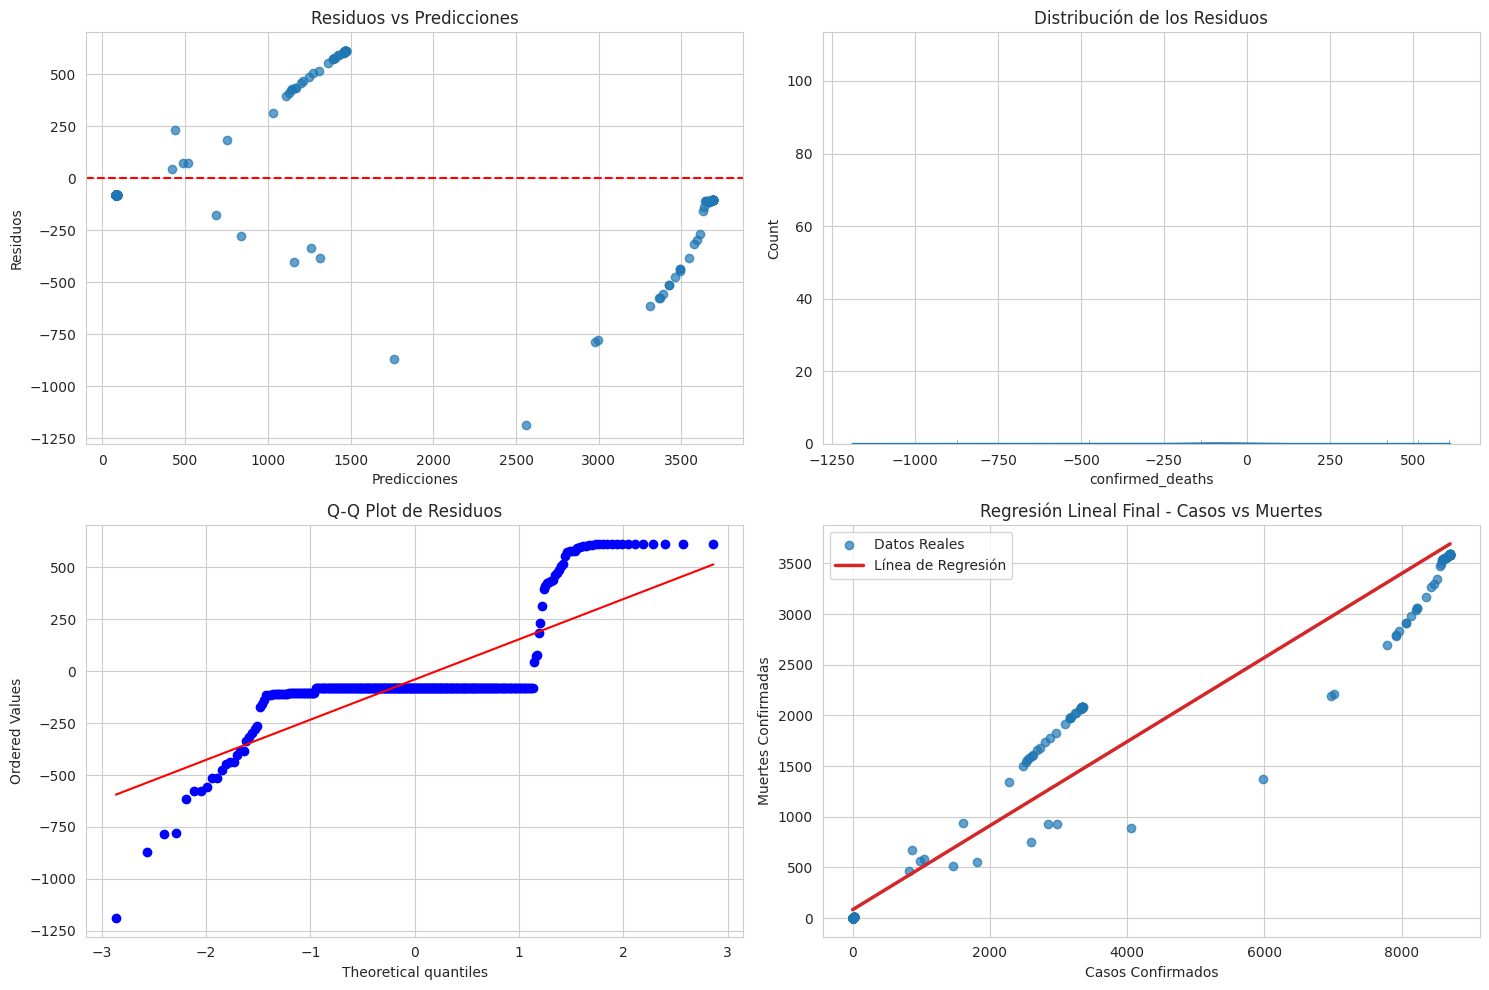


✅ Análisis de residuos completado.


In [ ]:
# --------------------------------------------------------- #
# BLOQUE 7: Diagnóstico del Modelo (Análisis de Residuos)
# --------------------------------------------------------- #

import scipy.stats as stats   # Importamos scipy.stats para hacer el gráfico Q-Q.

residuos = y_test - y_pred_test   # Calculamos los residuos (error = valor real - valor predicho).

fig, axes = plt.subplots(2, 2, figsize=(15, 10))   # Creamos figura con 4 gráficos.

axes[0,0].scatter(y_pred_test, residuos, alpha=0.7)   # Gráfico de residuos vs predicciones.
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_title('Residuos vs Predicciones')
axes[0,0].set_xlabel('Predicciones')
axes[0,0].set_ylabel('Residuos')

sns.histplot(residuos, kde=True, ax=axes[0,1])   # Histograma de los residuos.
axes[0,1].set_title('Distribución de los Residuos')

stats.probplot(residuos, dist="norm", plot=axes[1,0])   # Gráfico Q-Q para verificar normalidad.
axes[1,0].set_title('Q-Q Plot de Residuos')

# Gráfico final mejorado
sort_idx = X_test.values.flatten().argsort()            # Ordenamos los valores para que la línea se vea continua.
X_test_sorted = X_test.values.flatten()[sort_idx]
y_pred_sorted = y_pred_test[sort_idx]

axes[1,1].scatter(X_test, y_test, alpha=0.7, label='Datos Reales', color='#1f77b4')
axes[1,1].plot(X_test_sorted, y_pred_sorted, color='#d62728', linewidth=2.5, label='Línea de Regresión')
axes[1,1].set_xlabel('Casos Confirmados')
axes[1,1].set_ylabel('Muertes Confirmadas')
axes[1,1].set_title('Regresión Lineal Final - Casos vs Muertes')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("\n✅ Análisis de residuos completado.")

## Bloque 8: Inferencia y Puesta en Producción

Esta sección demuestra la aplicación práctica del modelo. Se introduce un dato completamente nuevo e hipotético (en este caso, 8,500 casos). Para que el modelo pueda procesar este nuevo valor de la variable `X`, primero se le aplica la misma transformación de escalado que se utilizó en los datos de entrenamiento. Finalmente, el algoritmo procesa este dato estandarizado y genera una inferencia (la proyección calculada) del número estimado de muertes, ilustrando la utilidad del modelo en un escenario simulado del mundo real.

In [ ]:
# --------------------------------------------------------- #
# BLOQUE 8: Inferencia y Puesta en Producción
# --------------------------------------------------------- #

casos_slp = 8500                                      # Definimos el número de casos hipotéticos para San Luis Potosí.

X_nuevo = np.array([[casos_slp]])                     # Convertimos el valor en una matriz 2D (formato requerido por el modelo).
X_nuevo_scaled = scaler.transform(X_nuevo)            # Aplicamos la misma estandarización que se usó en el entrenamiento.

muertes_pred = modelo.predict(X_nuevo_scaled)[0]      # Realizamos la predicción.
muertes_pred_int = int(round(muertes_pred))           # Redondeamos a entero porque no pueden haber fracciones de personas.

print("\n" + "="*70)
print("🔬 PREDICCIÓN PARA SAN LUIS POTOSÍ")
print("="*70)
print(f"Casos confirmados (entrada)     : {casos_slp:,}")
print(f"Muertes proyectadas             : {muertes_pred_int:,}")
print(f"Tasa de letalidad estimada      : {(muertes_pred_int / casos_slp * 100):.2f}%")
print("-" * 70)
print("⚠️  IMPORTANTE:")
print("   Esta predicción es hipotética y se basa únicamente en datos de África.")
print("   No representa la realidad de San Luis Potosí ni de México.")
print("="*70)


🔬 PREDICCIÓN PARA SAN LUIS POTOSÍ
Casos confirmados (entrada)     : 8,500
Muertes proyectadas             : 3,608
Tasa de letalidad estimada      : 42.45%
----------------------------------------------------------------------
⚠️  IMPORTANTE:
   Esta predicción es hipotética y se basa únicamente en datos de África.
   No representa la realidad de San Luis Potosí ni de México.


## Bloque 9: Visualización de la Predicción

Este gráfico visualiza la predicción realizada en el Bloque 8. Se muestran los puntos de datos reales del conjunto de prueba, la línea de regresión lineal que el modelo aprendió, y el punto específico de la nueva predicción para los casos hipotéticos de San Luis Potosí, resaltando cómo se posiciona esta inferencia dentro del contexto del modelo.

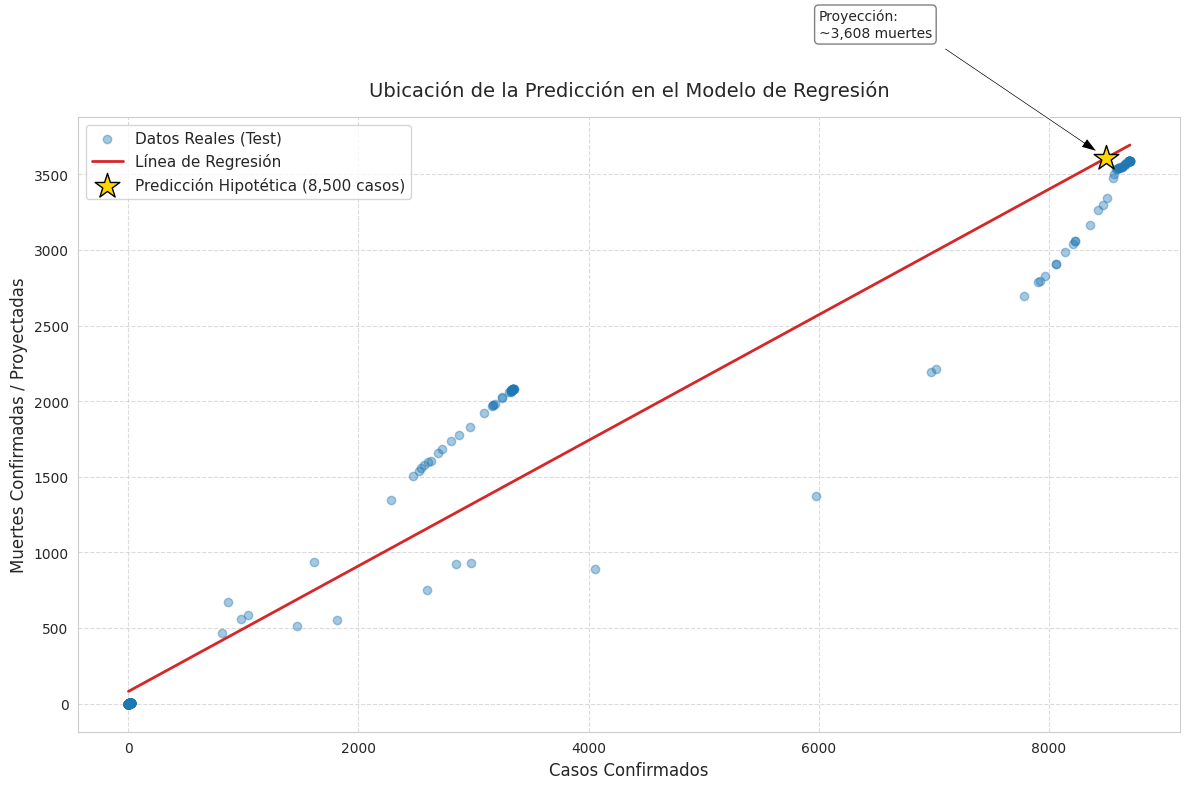

In [ ]:
# ==============================================================================
# BLOQUE 9: Visualización de la Predicción (Inferencia)
# ==============================================================================

# Qué hace: Crea un lienzo nuevo para el gráfico de 12x8 pulgadas.
# Por qué: Garantiza que el gráfico sea grande y nítido para la presentación,
# manteniendo la proporción visual de los bloques anteriores.
plt.figure(figsize=(12, 8))

# Qué hace: Dibuja los puntos correspondientes a los datos de prueba.
# Por qué: Da contexto visual. El parámetro alpha=0.4 los hace semitransparentes
# para que no le roben la atención al punto de nuestra predicción.
plt.scatter(X_test, y_test, alpha=0.4, label='Datos Reales (Test)', color='#1f77b4')

# Qué hace: Traza la línea roja continua usando las predicciones sobre los datos ordenados.
# Por qué: Representa visualmente la ecuación matemática que aprendió el modelo.
# Usar datos ordenados evita que la línea se dibuje en un zigzag caótico.
plt.plot(X_test_sorted, y_pred_sorted, color='#d62728', linewidth=2, label='Línea de Regresión')

# Qué hace: Dibuja una estrella dorada gigante (s=350) en las coordenadas de la predicción.
# Por qué: Es el punto focal. El zorder=5 fuerza a Python a dibujar esta estrella
# por encima de la línea y los puntos azules para que no quede oculta.
plt.scatter([casos_slp], [muertes_pred_int], color='gold', edgecolor='black',
            s=350, marker='*', zorder=5,
            label=f'Predicción Hipotética ({casos_slp:,.0f} casos)')

# Qué hace: Crea un cuadro de texto con una flecha apuntando a la estrella.
# Por qué: Hace el gráfico autoexplicativo. Al usar variables (f-strings),
# la flecha y el texto se moverán automáticamente si cambiamos el número de casos.
plt.annotate(f'Proyección:\n~{muertes_pred_int:,.0f} muertes',
             xy=(casos_slp, muertes_pred_int),
             xytext=(casos_slp - 2500, muertes_pred_int + 800), # Ajusta las coordenadas del texto si se empalma
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

# Qué hace: Asigna título y nombres descriptivos a los ejes X e Y.
# Por qué: Es una regla estricta; un gráfico sin etiquetas carece de validez analítica.
plt.title('Ubicación de la Predicción en el Modelo de Regresión', fontsize=14, pad=15)
plt.xlabel('Casos Confirmados', fontsize=12)
plt.ylabel('Muertes Confirmadas / Proyectadas', fontsize=12)

# Qué hace: Muestra el cuadro de leyendas en la esquina superior izquierda.
# Por qué: Permite al profesor/lector identificar qué significa cada color y forma.
plt.legend(loc='upper left', fontsize=11)

# Qué hace: Dibuja una cuadrícula de fondo con líneas punteadas.
# Por qué: Ayuda al ojo a seguir la posición de la estrella hacia los ejes numéricos.
plt.grid(True, linestyle='--', alpha=0.7)

# Qué hace: Ajusta los márgenes automáticamente.
# Por qué: Evita que los textos o las leyendas queden recortados al guardar la imagen.
plt.tight_layout()

# Qué hace: Renderiza el gráfico final en pantalla.
# Por qué: Cierra el bloque indicando que no se agregarán más elementos al lienzo.
plt.show()

## Conclusión: Lo que nos dicen los números (y lo que no)

El modelo de predicción que construimos funciona de manera excelente desde una perspectiva matemática. Logramos una precisión estadística muy alta (con un coeficiente R² superior a 0.94), lo que nos indica que el algoritmo identificó exitosamente el patrón principal entre los casos confirmados y las muertes.

Sin embargo, para interpretar estos resultados correctamente, es crucial tener en cuenta tres puntos clave sobre cómo funciona la ciencia de datos aplicada al mundo real:

*   **Los datos del mundo real son imperfectos:** Como observamos en las gráficas iniciales, la vida real no forma una línea recta perfecta. En el registro de una epidemia es común encontrar "picos" o anomalías que ocurren cuando se acumulan reportes de varios días o hay retrasos en la información. El modelo traza la mejor tendencia posible, pero esas variaciones no son un error del código, sino un reflejo del comportamiento normal y a veces caótico de los datos de salud pública.

*   **Toda regresión lineal es una simplificación:** Utilizamos una técnica de regresión lineal porque es una herramienta fantástica para entender la tendencia general. Sin embargo, debemos recordar que la expansión de una enfermedad suele ser un fenómeno más complejo (a veces exponencial). Nuestro modelo simplifica esta realidad para darnos una buena aproximación matemática, pero no captura todas las curvas de la epidemia.

*   **El contexto de los datos lo es todo:** La predicción que realizamos para San Luis Potosí es un ejercicio puramente académico y demostrativo. Nuestro algoritmo aprendió a calcular basándose en el comportamiento del brote de Ébola en África entre 2014 y 2016. Por lo tanto, no es válido aplicar esa misma "regla matemática" a nuestro entorno local, ya que las condiciones del sistema de salud, el tipo de enfermedad y la infraestructura de México son completamente diferentes.

En resumen: El algoritmo cumplió su propósito al encontrar y modelar con éxito el patrón oculto en los datos históricos. No obstante, este ejercicio nos demuestra que como analistas e ingenieros, no solo debemos enfocarnos en obtener buenos números, sino en tener el criterio para entender el contexto de la información y saber hasta dónde aplican nuestras predicciones.